[get_dataset_dir] Dataset found in /Users/matty_gee/nilearn_data/schaefer_2018

[get_dataset_dir] Dataset found in /Users/matty_gee/nilearn_data/fsl

/Users/matty_gee/miniconda3/envs/trajectories/lib/python3.11/site-packages/nilearn/image/resampling.py:688: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(
/Users/matty_gee/miniconda3/envs/trajectories/lib/python3.11/site-packages/nilearn/image/resampling.py:688: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(


Saved ../masks/atlases/Schaefer300300_HO-subcort25_1mm.pkl


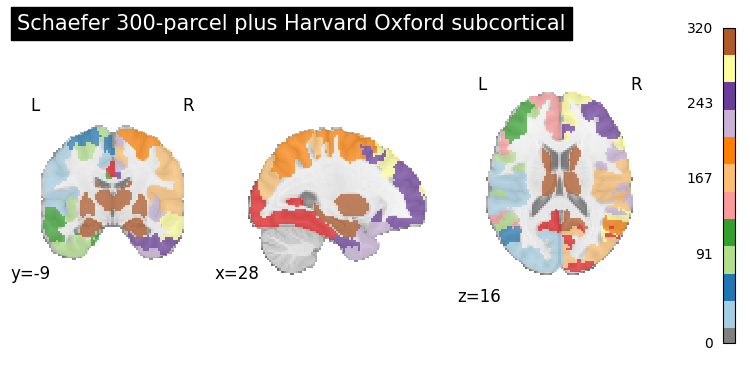

In [ ]:
from sklearn.utils import Bunch
import numpy as np
import nibabel as nib
import nilearn
from nilearn import datasets
from nilearn import image
from nilearn import plotting
from nilearn.maskers import NiftiLabelsMasker
from nilearn.input_data import NiftiMasker
from nilearn.image import resample_to_img
from nilearn.plotting import plot_roi
from nilearn.datasets import fetch_atlas_schaefer_2018, fetch_atlas_harvard_oxford
import matplotlib.pyplot as plt

def pickle_file(obj, fname):
    """Save an object to a pickle file."""
    import pickle
    with open(fname, 'wb') as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved {fname}")

# ------------------------------- Schaefer cortical parcellation atlas

n_schaefer = 300
schaefer_cort = datasets.fetch_atlas_schaefer_2018(
    n_rois=n_schaefer,   # 100–1000 parcels, in steps of 100
    yeo_networks=7,      # 7- or 17-networks
    resolution_mm=1      # 1 mm or 2 mm
)
cort_img  = nib.load(schaefer_cort.maps) 
cort_data = cort_img.get_fdata().astype(int) 


# ------------------------------- Havard Oxford subcortical parcellation atlas

harvard_oxford_subcort = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-1mm')
subcort_img  = harvard_oxford_subcort.maps
subcort_data = subcort_img.get_fdata().astype(int)

# exclude subcortical regions that are not of interest
subcort_labels = harvard_oxford_subcort.labels
to_exclude = {
    "Background",
    "Right Cerebral Cortex",
    "Left Cerebral Cortex",
    "Left Cerebral White Matter",
    "Right Cerebral White Matter",
    "Left Lateral Ventricle",
    "Right Lateral Ventricle",
    "Brain-Stem",
}
exclude_codes = {
    idx for idx, name in enumerate(subcort_labels)
    if name in to_exclude
}
subcort_data_clean = subcort_data.copy()
subcort_data_clean[np.isin(subcort_data_clean, list(exclude_codes))] = 0
subcort_img = nib.Nifti1Image(subcort_data_clean, subcort_img.affine, subcort_img.header)

# ------------------------------- merge cortical and subcortical atlases

# resample subcortical to cortical grid
subcort_img = image.resample_to_img(subcort_img, 
                                    target_img=cort_img, 
                                    interpolation='nearest', 
                                    force_resample=True, 
                                    copy_header=True) 
subcort_data = subcort_img.get_fdata().astype(int)

# merge labels with offset
max_cort = cort_data.max()
assert max_cort == n_schaefer, f"Cortical atlas should have {n_schaefer} parcels but has {max_cort}"
sub_offset = np.where(subcort_data > 0, subcort_data + max_cort, 0)
merged = np.where(cort_data > 0, cort_data, sub_offset) # cortex wins where nonzero, else subcortex
merged_img = nib.Nifti1Image(merged, cort_img.affine, cort_img.header)

# build roi_dict mapping integer → label
roi_dict = {}

# cortical codes that actually appear
for code in np.unique(cort_data):
    if code == 0: # skip background
        continue
    lbl = schaefer_cort.labels[code-1]
    roi_dict[int(code)] = str(lbl.decode('utf-8'))

# sub-cortical codes (after offset) that appear and are not excluded
for idx, lbl in enumerate(subcort_labels):
    if idx == 0 or idx in exclude_codes: # background or excluded
        continue
    new_code = int(idx + max_cort)
    if new_code in np.unique(sub_offset):
        roi_dict[new_code] = str(lbl)
    
missing = (set(np.unique(merged)) - {0}) - set(roi_dict.keys())
if missing: raise ValueError(f"Unmapped codes: {sorted(missing)}")

# ------------------------------- resample to our fmri space

beta_img = nib.load('../masks/example_image_for_resampling.nii.gz')  # Example image for resampling
merged_img = resample_to_img(
    source_img=merged_img,
    target_img=beta_img,
    interpolation="nearest", # "nearest" ensures the ROI labels are integer
    force_resample=True,  # Force resampling even if dimensions match
    copy_header=True,  # Copy header information from the target image
)


# ------------------------------- save atlas
# # nib.save(merged_img, f'../masks/atlases/Schaefer{n_schaefer}_HO-subcort25_1mm.nii.gz')
parcellation = Bunch(image=merged_img, rois=roi_dict)
pickle_file(parcellation, f'../masks/atlases/Schaefer{n_schaefer}_HO-subcort25_1mm.pkl')

nilearn.plotting.plot_roi(merged_img, 
                          title=f'Schaefer {n_schaefer}-parcel plus Harvard Oxford subcortical', 
                          draw_cross=False, 
                          colorbar=True, cmap='Paired')
plt.show()